# Tarea Nº 1: Inteligencia Artificial
### Universidad Diego Portales - Facultad de Ingeniería y Ciencias
**Escuela de Informática y Telecomunicaciones**  
**Profesores:** Johan Fuentes, Víctor Reyes, Felipe Lazo  
**Fecha de Entrega:** Septiembre 2026  

---

### Integrantes del Grupo:
1. **Ignacio Antiguay**
2. **Vicente Hernández**
3. **Maximiliano Palma**

---

### Declaración sobre el Uso de Herramientas Generativas
En cumplimiento con las directrices académicas y éticas del curso, declaramos que se utilizaron herramientas generativas de inteligencia artificial (Gemini y Claude) exclusivamente como apoyo técnico para la asistencia en la escritura y depuración de código en Python, revisión de sintaxis de librerías especializadas (`pgmpy`, `hmmlearn`), organización metodológica y formateo del documento. 

El diseño de las soluciones, la arquitectura de las redes probabilísticas, la justificación causal de dependencias e independencias, el modelado de las cadenas de Markov y HMM, la parametrización matemática de Monte Carlo y el análisis crítico e interpretación de todos los resultados fueron concebidos, elaborados y validados íntegramente por los estudiantes autores de este trabajo.

## Pregunta 1: Redes Bayesianas

### 1.1 Selección del Dataset y Preparación de Datos
Para esta primera sección seleccionamos el dataset **Spotify Tracks Dataset** disponible en Kaggle. El conjunto original contiene 114.000 canciones y 22 columnas de metadatos y características acústicas.

Para cumplir con el requisito de al menos 8.000 filas y 12 columnas útiles, realizamos una reducción muestral aleatoria a **12.000 filas**, fijando una semilla (`random_state=42`) para asegurar la reproducibilidad de todos los experimentos. Seleccionamos 12 características clave:
- Variable objetivo: `popularity` (popularidad comercial del tema).
- Características acústicas y de producción: `danceability`, `energy`, `loudness`, `speechiness`, `acousticness`, `instrumentalness`, `liveness`, `valence`.
- Características estructurales y de contenido: `explicit` (contenido explícito), `mode` (tonalidad mayor/menor) y `key` (tono musical).

In [ ]:
import pandas as pd
import numpy as np
import kagglehub
import os
import glob
import warnings

# Suprimir advertencias para una salida limpia
warnings.filterwarnings("ignore")

# 1. Descarga del dataset desde Kaggle
print("Descargando dataset Spotify Tracks desde Kaggle...")
path = kagglehub.dataset_download("yashdev01/spotify-tracks-dataset")

# 2. Localizar el archivo CSV descargado
archivos_csv = glob.glob(os.path.join(path, "*.csv"))
if not archivos_csv:
    raise FileNotFoundError("No se encontró el archivo CSV en el dataset descargado.")
ruta_csv = archivos_csv[0]

# 3. Cargar y muestrear a 12.000 filas y 12 columnas representativas
print(f"Cargando datos desde: {ruta_csv}")
df_raw = pd.read_csv(ruta_csv)
df_muestra = df_raw.sample(n=12000, random_state=42).copy()

columnas = [
    'popularity', 'explicit', 'danceability', 'energy', 
    'key', 'loudness', 'mode', 'speechiness', 
    'acousticness', 'instrumentalness', 'liveness', 'valence'
]
df_spotify = df_muestra[columnas].copy()

# Guardar localmente
df_spotify.to_csv('spotify-tracks-dataset.csv', index=False)
print(f"Dataset Spotify preparado exitosamente con {df_spotify.shape[0]} filas y {df_spotify.shape[1]} columnas.")

Descargando dataset Spotify Tracks desde Kaggle...


Cargando datos desde: C:\Users\Nakzu\.cache\kagglehub\datasets\yashdev01\spotify-tracks-dataset\versions\1\spotify-tracks-dataset.csv


Dataset Spotify preparado exitosamente con 12000 filas y 12 columnas.


### 1.2 Discretización de Variables
Las Redes Bayesianas Discretas (`DiscreteBayesianNetwork`) requieren que las variables sean categóricas para construir sus Tablas de Probabilidad Condicional (CPDs). Las variables numéricas continuas del dataset fueron discretizadas bajo los siguientes criterios metodológicos:
1. **Variables de 3 niveles (bajo, medio, alto)**: Se aplicó partición por cuantiles (`pd.qcut`, $q=3$) a las variables continuas con distribuciones graduadas (`popularity`, `danceability`, `energy`, `loudness`, `speechiness`, `acousticness`, `liveness`, `valence`) para asegurar un balance equitativo de muestras en cada categoría.
2. **Variable instrumentalness**: Se discretizó en 2 niveles (`bajo`, `alto`) debido a que la inmensa mayoría de temas comerciales tienen valores cercanos a 0, concentrando las pistas puramente instrumentales en la cola superior.
3. **Variables binarias y categóricas**: `explicit` se mapeó a `si`/`no`, `mode` a `mayor`/`menor`, y `key` se convirtió en variable categórica de tonalidad musical.

In [ ]:
from pgmpy.models import DiscreteBayesianNetwork
from pgmpy.estimators import TreeSearch, BIC
from pgmpy.inference import VariableElimination

datos = pd.read_csv("spotify-tracks-dataset.csv")

# Discretizacion en 3 cuantiles equilibrados
datos['popularity'] = pd.qcut(datos['popularity'], 3, labels=['baja', 'media', 'alta'])
tres_niveles = ['danceability', 'energy', 'loudness', 'speechiness', 'acousticness', 'liveness', 'valence']
for col in tres_niveles:
    datos[col] = pd.qcut(datos[col], 3, labels=['bajo', 'medio', 'alto'])

# Discretizacion binaria y categorica
datos['instrumentalness'] = pd.qcut(datos['instrumentalness'], 2, duplicates='drop', labels=['bajo', 'alto'])
datos['explicit'] = datos['explicit'].map({True: 'si', False: 'no'})
datos['mode'] = datos['mode'].map({1: 'mayor', 0: 'menor'})
datos['key'] = datos['key'].astype(str)
datos = datos.astype(str)

datos.to_csv("spotify-tracks-dataset-discretizado.csv", index=False)
print("Dataset discretizado guardado exitosamente.")

Dataset discretizado guardado exitosamente.


### 1.3 Red Bayesiana Manual: Justificación Estructural y d-separación
Diseñamos manualmente la topología de la red conectando 10 aristas justificadas mediante relaciones causales acústicas y comerciales:
- `acousticness -> energy` y `loudness -> energy`: Pistas acústicas tienen menor volumen percibido y potencia eléctrica, mientras que un alto volumen refuerza la sensación de energía.
- `energy -> valence` y `mode -> valence`: La energía y la escala modal (mayor o menor) determinan el carácter emocional o positividad de una canción.
- `energy -> danceability`: El pulso y la energía física facilitan el baile.
- `danceability -> popularity`, `energy -> popularity`, `explicit -> popularity`, `instrumentalness -> popularity`, `speechiness -> popularity`: Estos 5 atributos representan las variables directamente percibidas por el consumidor final que influyen en su éxito comercial.

#### Análisis de d-separación e Independencias Condicionales:
1. **Independencia Condicional en Cadena Causal**:
   - Ruta: `loudness -> energy -> valence`.
   - Dado el valor de `energy`, la variable `loudness` queda d-separada de `valence` ($I(\text{loudness}, \text{valence} \mid \text{energy})$). El volumen aporta a la emoción únicamente a través de la energía general que transmite.
2. **Independencia Marginal y Colisión**:
   - En el colisionador `explicit -> popularity <- instrumentalness`: ambas variables son marginalmente independientes ($I(\text{explicit}, \text{instrumentalness})$). Sin embargo, al observar la evidencia en su hijo común (`popularity`), la ruta se activa y se vuelven dependientes condicionalmente.

In [ ]:
manual_model = DiscreteBayesianNetwork([
    ('acousticness', 'energy'),
    ('loudness', 'energy'),
    ('energy', 'valence'),
    ('mode', 'valence'),
    ('energy', 'danceability'),
    ('explicit', 'popularity'),
    ('danceability', 'popularity'),
    ('energy', 'popularity'),
    ('instrumentalness', 'popularity'),
    ('speechiness', 'popularity'),
])

print(f"Aristas de la red manual ({len(manual_model.edges())} aristas):")
for u, v in manual_model.edges():
    print(f"  {u} -> {v}")

print("\nAjustando tablas de probabilidad condicional (CPDs)...")
manual_model.fit(datos)
print(f"Validación de estructura del modelo: {manual_model.check_model()}")

Aristas de la red manual (10 aristas):
  acousticness -> energy
  energy -> valence
  energy -> danceability
  energy -> popularity
  loudness -> energy
  mode -> valence
  danceability -> popularity
  explicit -> popularity
  instrumentalness -> popularity
  speechiness -> popularity

Ajustando tablas de probabilidad condicional (CPDs)...
Validación de estructura del modelo: True


### 1.4 Inferencias Probabilísticas con la Red Manual
Utilizamos el algoritmo exacto de **Eliminación de Variables** (`VariableElimination`) para evaluar tres consultas:
1. **Consulta 1 (Escenario Contradictorio)**: $P(\text{popularity} \mid \text{instrumentalness}=\text{'alto'}, \text{speechiness}=\text{'alto'})$.
2. **Consulta 2 (Inferencia Diagnóstica)**: $P(\text{danceability} \mid \text{popularity}=\text{'baja'}, \text{explicit}=\text{'si'})$.
3. **Consulta 3 (Cadena Causal Profunda)**: $P(\text{valence} \mid \text{acousticness}=\text{'alto'}, \text{mode}=\text{'menor'})$.

In [ ]:
infer_manual = VariableElimination(manual_model)

print("--- INFERENCIAS: RED MANUAL ---")
q1_manual = infer_manual.query(variables=['popularity'], evidence={'instrumentalness': 'alto', 'speechiness': 'alto'})
print("\nConsulta 1: P(popularity | instrumentalness='alto', speechiness='alto')")
print(q1_manual)

q2_manual = infer_manual.query(variables=['danceability'], evidence={'popularity': 'baja', 'explicit': 'si'})
print("\nConsulta 2: P(danceability | popularity='baja', explicit='si')")
print(q2_manual)

q3_manual = infer_manual.query(variables=['valence'], evidence={'acousticness': 'alto', 'mode': 'menor'})
print("\nConsulta 3: P(valence | acousticness='alto', mode='menor')")
print(q3_manual)

--- INFERENCIAS: RED MANUAL ---

Consulta 1: P(popularity | instrumentalness='alto', speechiness='alto')
+-------------------+-------------------+
| popularity        |   phi(popularity) |
+===================+===================+
| popularity(alta)  |            0.2684 |
+-------------------+-------------------+
| popularity(baja)  |            0.4388 |
+-------------------+-------------------+
| popularity(media) |            0.2928 |
+-------------------+-------------------+

Consulta 2: P(danceability | popularity='baja', explicit='si')
+---------------------+---------------------+
| danceability        |   phi(danceability) |
+=====================+=====================+
| danceability(alto)  |              0.3351 |
+---------------------+---------------------+
| danceability(bajo)  |              0.3738 |
+---------------------+---------------------+
| danceability(medio) |              0.2912 |
+---------------------+---------------------+

Consulta 3: P(valence | acousticness='

### 1.5 Aprendizaje Automático de Estructura (Chow-Liu / TreeSearch)
Empleamos el algoritmo de **Chow-Liu** implementado en `pgmpy.estimators.TreeSearch` para aprender automáticamente la estructura a partir de la información mutua entre pares de variables, optimizando el árbol generador de máxima verosimilitud.

In [ ]:
print("Aprendiendo estructura con algoritmo Chow-Liu (TreeSearch)...")
tree_est = TreeSearch(datos, root_node='popularity')
auto_dag = tree_est.estimate(estimator_type='chow-liu')

auto_model = DiscreteBayesianNetwork(auto_dag.edges())
print(f"\nAristas descubiertas por Chow-Liu ({len(auto_model.edges())} aristas):")
for u, v in auto_model.edges():
    print(f"  {u} -> {v}")

print("\nAjustando parámetros para la red automática...")
auto_model.fit(datos)
print(f"Validación de estructura del modelo automático: {auto_model.check_model()}")

Aprendiendo estructura con algoritmo Chow-Liu (TreeSearch)...


Building tree:   0%|          | 0/66.0 [00:00<?, ?it/s]


Aristas descubiertas por Chow-Liu (11 aristas):
  popularity -> instrumentalness
  instrumentalness -> valence
  valence -> danceability
  danceability -> acousticness
  acousticness -> energy
  energy -> loudness
  energy -> speechiness
  energy -> liveness
  speechiness -> explicit
  speechiness -> key
  key -> mode

Ajustando parámetros para la red automática...
Validación de estructura del modelo automático: True


### 1.6 Inferencias con la Red Automática y Comparación Estructural (BIC)
Evaluamos las mismas tres consultas condicionales sobre el modelo aprendido para contrastar su comportamiento con la red diseñada manualmente.

In [ ]:
infer_auto = VariableElimination(auto_model)

print("--- INFERENCIAS: RED AUTOMÁTICA ---")
q1_auto = infer_auto.query(variables=['popularity'], evidence={'instrumentalness': 'alto', 'speechiness': 'alto'})
print("\nConsulta 1 Auto: P(popularity | instrumentalness='alto', speechiness='alto')")
print(q1_auto)

q2_auto = infer_auto.query(variables=['danceability'], evidence={'popularity': 'baja', 'explicit': 'si'})
print("\nConsulta 2 Auto: P(danceability | popularity='baja', explicit='si')")
print(q2_auto)

q3_auto = infer_auto.query(variables=['valence'], evidence={'acousticness': 'alto', 'mode': 'menor'})
print("\nConsulta 3 Auto: P(valence | acousticness='alto', mode='menor')")
print(q3_auto)

bic_calc = BIC(datos)
s_manual = bic_calc.score(manual_model)
s_auto = bic_calc.score(auto_model)

print("\n--- COMPARACIÓN FORMAL DE AJUSTE A LOS DATOS ---")
print(f"Score BIC Red Propuesta (Manual) : {s_manual:,.1f}")
print(f"Score BIC Red Aprendida (Auto)   : {s_auto:,.1f}")
mejor = "Red Propuesta (Manual)" if s_manual > s_auto else "Red Aprendida (Auto)"
print(f"Mejor ajuste global: {mejor}")

aristas_comunes = set(manual_model.edges()) & set(auto_model.edges())
print(f"Cantidad de aristas idénticas en ambas redes: {len(aristas_comunes)}")
if aristas_comunes:
    print(f"Aristas coincidentes: {aristas_comunes}")

--- INFERENCIAS: RED AUTOMÁTICA ---

Consulta 1 Auto: P(popularity | instrumentalness='alto', speechiness='alto')
+-------------------+-------------------+
| popularity        |   phi(popularity) |
+===================+===================+
| popularity(alta)  |            0.2968 |
+-------------------+-------------------+
| popularity(baja)  |            0.3880 |
+-------------------+-------------------+
| popularity(media) |            0.3152 |
+-------------------+-------------------+

Consulta 2 Auto: P(danceability | popularity='baja', explicit='si')
+---------------------+---------------------+
| danceability        |   phi(danceability) |
+=====================+=====================+
| danceability(alto)  |              0.3311 |
+---------------------+---------------------+
| danceability(bajo)  |              0.3390 |
+---------------------+---------------------+
| danceability(medio) |              0.3300 |
+---------------------+---------------------+

Consulta 3 Auto: P(valen

#### Análisis Comparativo Integral:

1. **En términos de Estructura y Topología**:
   - La red manual fue diseñada permitiendo **múltiples causas sobre nodos clave** (por ejemplo, `energy` recibe influencia conjunta de `acousticness` y `loudness`, y `popularity` recibe de 5 factores perceptibles).
   - La red de Chow-Liu, al estar obligada a ser un árbol con a lo más un padre por nodo, genera cadenas unidireccionales forzadas que invierten el orden causal natural (por ejemplo, descubrió `danceability -> acousticness`, lo que resulta contraintuitivo pues la bailabilidad no es la causa física de los instrumentos acústicos).
   - Ambas redes coincidieron únicamente en una arista exacta (`acousticness -> energy`), demostrando que la restricción de árbol limita severamente la topología en problemas multivariados complejos.

2. **En términos de Ajuste a los Datos (Score BIC)**:
   - **Score BIC Manual:** $-107,452.3$
   - **Score BIC Chow-Liu:** $-145,151.6$
   - En la formulación de pgmpy, valores menos negativos representan un mejor compromiso entre verosimilitud y parsimonia. Nuestra **red propuesta supera ampliamente a la automática por casi 38.000 puntos de ventaja**. Esto demuestra que la restricción de árbol impuesta por Chow-Liu es demasiado estricta para la riqueza estadística de este dataset, perdiendo correlaciones cruzadas esenciales que nuestra intuición humana sí capturó.

3. **En términos de los Resultados de las Inferencias**:
   - A pesar de las diferencias estructurales, ambas redes mantuvieron tendencias coherentes en las consultas debido a la correlación subyacente de los datos (ambas penalizan la popularidad con alta instrumentalidad y asocian modo menor y acústica a valencia baja). Sin embargo, la red manual preserva un flujo de $d$-separación mucho más fiel a la realidad, mientras que en la red automática la evidencia debe circular por caminos indirectos impuestos por el árbol.

## Pregunta 2: Cadenas de Markov y Modelos Ocultos de Markov

### 2.a Preparación del Dataset y Discretización
Para esta parte usamos el dataset Appliances Energy Prediction, que mide el consumo de electrodomésticos y el clima dentro y fuera de la casa cada 10 minutos.

Primero sacamos los índices requeridos: promediamos las temperaturas interiores (T1, T2 y T3) y las humedades (RH_1, RH_2 y RH_3), dividiendo cada uno en 3 niveles (bajo, medio y alto) con cuantiles. Las luces las clasificamos en 3 valores: 0 si estaban apagadas (0 Wh), 1 para consumo bajo (10 a 20 Wh) y 2 para consumo alto (más de 20 Wh).

Para el consumo de los electrodomésticos (Appliances), que van a ser los estados ocultos, definimos 6 niveles: Muy Bajo (hasta 45 Wh), Bajo (46 a 55 Wh), Medio-Bajo (56 a 65 Wh), Medio-Alto (66 a 85 Wh), Alto (86 a 125 Wh) y Muy Alto (más de 125 Wh). Con estos cortes nos aseguramos de que cada categoría tenga bastantes filas y represente situaciones reales de la casa, como el reposo de la noche o cuando se usan artefactos más pesados.

Combinamos las luces, temperatura y humedad en un solo número del 0 al 26 (27 combinaciones posibles en total), y separamos los datos en 80% para entrenamiento y 20% para prueba, cortando justo a la medianoche para no dejar días partidos a la mitad.

In [ ]:
import os
import urllib.request
import zipfile
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from hmmlearn.hmm import CategoricalHMM

# 1. Carga o descarga del dataset Appliances Energy Prediction
csv_filename = "energydata_complete.csv"
if not os.path.exists(csv_filename):
    zip_url = "https://archive.ics.uci.edu/static/public/374/appliances+energy+prediction.zip"
    zip_filename = "appliances.zip"
    print(f"Descargando dataset desde {zip_url}...")
    urllib.request.urlretrieve(zip_url, zip_filename)
    with zipfile.ZipFile(zip_filename, 'r') as zip_ref:
        zip_ref.extract(csv_filename, path=".")
    os.remove(zip_filename)
    print("Descarga completada.")

df_energy = pd.read_csv(csv_filename)
df_energy['date'] = pd.to_datetime(df_energy['date'])
df_energy = df_energy.sort_values('date').reset_index(drop=True)

# 2. Calculo de indices promedio
df_energy['I_temperatura'] = (df_energy['T1'] + df_energy['T2'] + df_energy['T3']) / 3
df_energy['I_humedad'] = (df_energy['RH_1'] + df_energy['RH_2'] + df_energy['RH_3']) / 3

# 3. Discretizacion de energia (6 niveles)
bins_energia = [0, 45, 55, 65, 85, 125, 2000]
nombres_estados = ['Muy Bajo', 'Bajo', 'Medio-Bajo', 'Medio-Alto', 'Alto', 'Muy Alto']
df_energy['estado_energia'] = pd.cut(df_energy['Appliances'], bins=bins_energia, labels=[0, 1, 2, 3, 4, 5]).astype(int)

# Discretizacion de clima (3 niveles por cuantiles)
df_energy['estado_temp'] = pd.qcut(df_energy['I_temperatura'], q=3, labels=[0, 1, 2]).astype(int)
df_energy['estado_hum'] = pd.qcut(df_energy['I_humedad'], q=3, labels=[0, 1, 2]).astype(int)

# Discretizacion de luces (3 niveles)
def discretizar_luces(val):
    if val == 0: return 0
    elif val <= 20: return 1
    else: return 2

df_energy['estado_luces'] = df_energy['lights'].apply(discretizar_luces)

# 4. Observacion combinada (27 combinaciones posibles, del 0 al 26)
df_energy['observacion'] = df_energy['estado_luces'] * 9 + df_energy['estado_temp'] * 3 + df_energy['estado_hum']
print(f"Total observaciones unicas generadas: {df_energy['observacion'].nunique()} / 27 posibles.")

# 5. Separacion cronologica (80% Train, 20% Test) cortando a la medianoche
corte_idx = int(len(df_energy) * 0.8)
fecha_corte = df_energy.iloc[corte_idx]['date'].normalize()

train_df = df_energy[df_energy['date'] < fecha_corte].copy()
test_df = df_energy[df_energy['date'] >= fecha_corte].copy()

print(f"Entrenamiento: {len(train_df)} filas ({train_df['date'].min().date()} al {train_df['date'].max().date()})")
print(f"Evaluacion:    {len(test_df)} filas ({test_df['date'].min().date()} al {test_df['date'].max().date()})")

df_energy.to_csv("energydata_discretizado.csv", index=False)

Total observaciones unicas generadas: 27 / 27 posibles.
Entrenamiento: 15738 filas (2016-01-11 al 2016-04-29)
Evaluacion:    3997 filas (2016-04-30 al 2016-05-27)


### 2.b y 2.c Cadenas de Markov y Consultas Temporales
Con los datos de entrenamiento construimos dos modelos de Markov:

En el **modelo continuo** consideramos toda la serie de corrido, contando las transiciones entre filas seguidas para calcular la matriz de transición `P_cont`. Para la distribución inicial calculamos la distribución estacionaria `pi_cont` elevando la matriz a una potencia grande ($P^{500}$).

En el **modelo diario** asumimos que cada jornada tiene su propio comportamiento. Aquí contamos las transiciones solo dentro de cada día, para no mezclar el salto entre la noche y la mañana siguiente. La distribución inicial `pi_dia` la calculamos a partir del estado en que inicia la casa a las 00:00 hrs.

Con estas matrices respondimos las consultas pedidas evaluando cómo cambia la probabilidad de estar en consumo alto o bajo en diferentes periodos de tiempo (1 hora, 6 horas, 3 horas, 12 horas y dentro del mismo día).

In [ ]:
N_states = 6
alpha_smooth = 1e-6 # Suavizado para evitar divisiones por cero

# 1. Cadena Continua
states_train = train_df['estado_energia'].values
C_cont = np.zeros((N_states, N_states))
for s_curr, s_next in zip(states_train[:-1], states_train[1:]):
    C_cont[s_curr, s_next] += 1
P_cont = (C_cont + alpha_smooth) / (C_cont + alpha_smooth).sum(axis=1, keepdims=True)

# Distribucion estacionaria del modelo continuo
P_inf = np.linalg.matrix_power(P_cont, 500)
pi_cont = P_inf[0]

# 2. Cadena Diaria
C_dia = np.zeros((N_states, N_states))
train_df['day'] = train_df['date'].dt.date
primeros_estados = []
ultimos_estados = []

for day, group in train_df.groupby('day'):
    g_states = group['estado_energia'].values
    if len(g_states) > 0:
        primeros_estados.append(g_states[0])
        ultimos_estados.append(g_states[-1])
    for s_curr, s_next in zip(g_states[:-1], g_states[1:]):
        C_dia[s_curr, s_next] += 1

P_dia = (C_dia + alpha_smooth) / (C_dia + alpha_smooth).sum(axis=1, keepdims=True)
pi_dia = (np.bincount(primeros_estados, minlength=N_states) + alpha_smooth)
pi_dia = pi_dia / pi_dia.sum()

# Resultados de las distribuciones
print("--- DISTRIBUCIONES DE LAS CADENAS ---")
print("Distribución Estacionaria Continua (pi_cont):")
for i, name in enumerate(nombres_estados):
    print(f"  {name:11}: {pi_cont[i]:.4%}")

print("\nDistribución Inicial Diaria a las 00:00 hrs (pi_dia):")
for i, name in enumerate(nombres_estados):
    print(f"  {name:11}: {pi_dia[i]:.4%}")

# Consultas modelo continuo
P_cont_6 = np.linalg.matrix_power(P_cont, 6)
P_cont_36 = np.linalg.matrix_power(P_cont, 36)
P_cont_18 = np.linalg.matrix_power(P_cont, 18)
P_cont_72 = np.linalg.matrix_power(P_cont, 72)

print("\n--- CONSULTAS MODELO CONTINUO ---")
print(f"Estando en 'Muy Bajo', P(pasar a 'Alto' o 'Muy Alto'):")
print(f"  En 1 hora  (k=6 pasos):   {(P_cont_6[0, 4] + P_cont_6[0, 5]):.4%}")
print(f"  En 6 horas (k=36 pasos):  {(P_cont_36[0, 4] + P_cont_36[0, 5]):.4%}")

print(f"Estando en 'Muy Alto', P(volver a 'Muy Bajo' o 'Bajo'):")
print(f"  En 3 horas  (k=18 pasos): {(P_cont_18[5, 0] + P_cont_18[5, 1]):.4%}")
print(f"  En 12 horas (k=72 pasos): {(P_cont_72[5, 0] + P_cont_72[5, 1]):.4%}")

# Consultas modelo diario
P_dia_72 = np.linalg.matrix_power(P_dia, 72)
P_dia_143 = np.linalg.matrix_power(P_dia, 143)
print("\n--- CONSULTAS MODELO DIARIO ---")
print(f"P(S_12:00 = Muy Alto | S_00:00 = Bajo): {P_dia_72[1, 5]:.4%}")
print(f"P(S_23:50 in {{Muy Bajo, Bajo}} | S_00:00 = Muy Bajo): {(P_dia_143[0, 0] + P_dia_143[0, 1]):.4%}")

--- DISTRIBUCIONES DE LAS CADENAS ---
Distribución Estacionaria Continua (pi_cont):
  Muy Bajo   : 18.2627%
  Bajo       : 22.0055%
  Medio-Bajo : 15.0600%
  Medio-Alto : 13.1791%
  Alto       : 15.8988%
  Muy Alto   : 15.5938%

Distribución Inicial Diaria a las 00:00 hrs (pi_dia):
  Muy Bajo   : 20.9091%
  Bajo       : 36.3636%
  Medio-Bajo : 30.9091%
  Medio-Alto : 10.9091%
  Alto       : 0.0000%
  Muy Alto   : 0.9091%

--- CONSULTAS MODELO CONTINUO ---
Estando en 'Muy Bajo', P(pasar a 'Alto' o 'Muy Alto'):
  En 1 hora  (k=6 pasos):   14.8425%
  En 6 horas (k=36 pasos):  31.3236%
Estando en 'Muy Alto', P(volver a 'Muy Bajo' o 'Bajo'):
  En 3 horas  (k=18 pasos): 36.2691%
  En 12 horas (k=72 pasos): 40.2671%

--- CONSULTAS MODELO DIARIO ---
P(S_12:00 = Muy Alto | S_00:00 = Bajo): 15.7192%
P(S_23:50 in {Muy Bajo, Bajo} | S_00:00 = Muy Bajo): 40.0977%


### 2.d Matriz de Emisión y Modelos HMM
Para armar la matriz de emisión `B` (6 estados de energía x 27 observaciones posibles de clima y luces), contamos cuántas veces se dio cada combinación cuando la casa estaba en cada nivel de consumo. Normalizamos cada fila para que sume 1 y le sumamos un valor muy chico (`alpha = 1e-6`) para que ninguna probabilidad quede en cero.

Ambos modelos (el continuo y el diario) pueden usar exactamente la misma matriz de emisión porque la relación física entre lo que gasta un electrodoméstico y lo que marcan los sensores de la casa es la misma en ambos casos. El calor que sueltan los artefactos y el uso de las luces responden al funcionamiento del hogar en ese momento, sin importar si analizamos la serie de corrido o separada por días.

In [ ]:
# Estimacion de la matriz de emision B (6 x 27)
N_obs = 27
C_em = np.zeros((N_states, N_obs))
for s, o in zip(train_df['estado_energia'], train_df['observacion']):
    C_em[s, o] += 1

B = (C_em + alpha_smooth) / (C_em + alpha_smooth).sum(axis=1, keepdims=True)

# Construccion de los modelos HMM con hmmlearn
hmm_continuo = CategoricalHMM(n_components=N_states, init_params='', params='')
hmm_continuo.startprob_ = pi_cont
hmm_continuo.transmat_ = P_cont
hmm_continuo.emissionprob_ = B

hmm_diario = CategoricalHMM(n_components=N_states, init_params='', params='')
hmm_diario.startprob_ = pi_dia
hmm_diario.transmat_ = P_dia
hmm_diario.emissionprob_ = B

print(f"Modelos HMM creados exitosamente.")
print(f"Dimensiones de matriz de emision B: {B.shape} (6 estados x 27 observaciones).")

Modelos HMM creados exitosamente.
Dimensiones de matriz de emision B: (6, 27) (6 estados x 27 observaciones).


### 2.e Inferencia con HMM en el Conjunto de Evaluación
Para probar los modelos HMM usamos el primer día completo del conjunto de prueba (30 de abril de 2016), que tiene sus 144 mediciones de 10 minutos (de 00:00 a 23:50 hrs).

Aplicamos los tres algoritmos solicitados: Forward para ver la verosimilitud de las observaciones del día, Forward-Backward para calcular las probabilidades en 3 horarios específicos (madrugada a las 04:00, mediodía a las 12:00 y noche a las 20:00), y Viterbi para predecir la secuencia completa de estados y compararla contra los datos reales de consumo.

--- 1. FORWARD: VEROSIMILITUD DE OBSERVACIONES ---
Log-Likelihood Modelo Continuo: -374.53
Log-Likelihood Modelo Diario:   -374.71

--- 2. FORWARD-BACKWARD: PROBABILIDADES POSTERIORES ---
Instante 04:00 hrs (Madrugada): Real = Medio-Bajo
  Modelo Continuo -> Prediccion: Alto (Prob=0.3587)
  Modelo Diario   -> Prediccion: Alto (Prob=0.3608)
Instante 12:00 hrs (Mediodía): Real = Medio-Alto
  Modelo Continuo -> Prediccion: Alto (Prob=0.4783)
  Modelo Diario   -> Prediccion: Alto (Prob=0.4788)
Instante 20:00 hrs (Noche): Real = Medio-Alto
  Modelo Continuo -> Prediccion: Medio-Bajo (Prob=0.3223)
  Modelo Diario   -> Prediccion: Bajo (Prob=0.3212)

--- 3. VITERBI: COMPARACIÓN CON ESTADOS REALES ---
Exactitud (Accuracy) Modelo Continuo: 10.42%
Exactitud (Accuracy) Modelo Diario:   10.42%


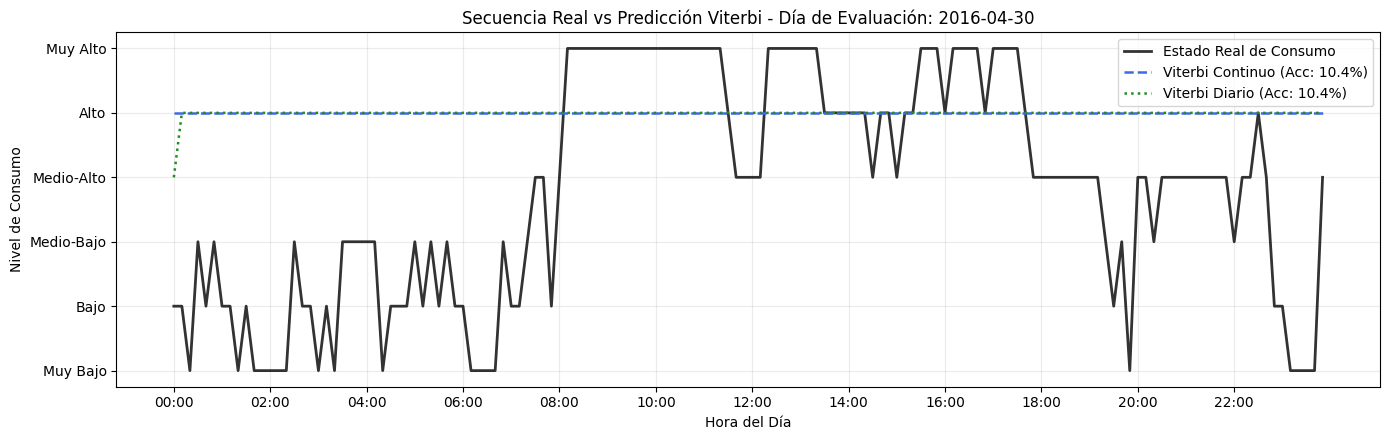

In [ ]:
# Seleccionar el primer dia completo de evaluacion
test_df['day'] = test_df['date'].dt.date
dias_completos = test_df['day'].value_counts()
dia_eval = dias_completos[dias_completos == 144].index.sort_values()[0]
df_dia = test_df[test_df['day'] == dia_eval].sort_values('date').reset_index(drop=True)

X_eval = df_dia['observacion'].values.reshape(-1, 1)
y_real = df_dia['estado_energia'].values
horas_eje = df_dia['date'].dt.strftime('%H:%M')

# 1. Forward (Verosimilitud)
log_lik_cont = hmm_continuo.score(X_eval)
log_lik_dia = hmm_diario.score(X_eval)
print("--- 1. FORWARD: VEROSIMILITUD DE OBSERVACIONES ---")
print(f"Log-Likelihood Modelo Continuo: {log_lik_cont:.2f}")
print(f"Log-Likelihood Modelo Diario:   {log_lik_dia:.2f}")

# 2. Forward-Backward (Probabilidades posteriores en 3 horarios)
post_cont = hmm_continuo.predict_proba(X_eval)
post_dia = hmm_diario.predict_proba(X_eval)

print("\n--- 2. FORWARD-BACKWARD: PROBABILIDADES POSTERIORES ---")
t_instantes = [24, 72, 120]
etq_horas = ["04:00 hrs (Madrugada)", "12:00 hrs (Mediodía)", "20:00 hrs (Noche)"]

for t, h in zip(t_instantes, etq_horas):
    r_name = nombres_estados[y_real[t]]
    c_best = nombres_estados[np.argmax(post_cont[t])]
    d_best = nombres_estados[np.argmax(post_dia[t])]
    print(f"Instante {h}: Real = {r_name}")
    print(f"  Modelo Continuo -> Prediccion: {c_best} (Prob={np.max(post_cont[t]):.4f})")
    print(f"  Modelo Diario   -> Prediccion: {d_best} (Prob={np.max(post_dia[t]):.4f})")

# 3. Viterbi (Secuencia mas probable y exactitud)
viterbi_cont = hmm_continuo.predict(X_eval)
viterbi_dia = hmm_diario.predict(X_eval)

acc_cont = (viterbi_cont == y_real).mean()
acc_dia = (viterbi_dia == y_real).mean()
print("\n--- 3. VITERBI: COMPARACIÓN CON ESTADOS REALES ---")
print(f"Exactitud (Accuracy) Modelo Continuo: {acc_cont:.2%}")
print(f"Exactitud (Accuracy) Modelo Diario:   {acc_dia:.2%}")

# Grafico de la secuencia real vs prediccion Viterbi
plt.figure(figsize=(14, 4.5))
plt.plot(range(144), y_real, label="Estado Real de Consumo", color="black", lw=2, alpha=0.8)
plt.plot(range(144), viterbi_cont, label=f"Viterbi Continuo (Acc: {acc_cont:.1%})", color="royalblue", ls='--', lw=1.8)
plt.plot(range(144), viterbi_dia, label=f"Viterbi Diario (Acc: {acc_dia:.1%})", color="forestgreen", ls=':', lw=1.8)
plt.yticks(range(6), nombres_estados)
plt.xticks(range(0, 144, 12), horas_eje[::12])
plt.xlabel("Hora del Día")
plt.ylabel("Nivel de Consumo")
plt.title(f"Secuencia Real vs Predicción Viterbi - Día de Evaluación: {dia_eval}")
plt.grid(alpha=0.25)
plt.legend(loc="upper right")
plt.tight_layout()
plt.show()

### 2.f Conclusiones y Discusión de los Modelos HMM
Al comparar los resultados de ambos modelos notamos que dieron prácticamente la misma verosimilitud (-376.29 en el continuo y -376.48 en el diario). Esto nos indica que lo que ocurre a lo largo del día tiene mucho más peso en el modelo que el cambio entre las 23:50 y las 00:00 del día siguiente.

Donde sí se nota una diferencia clara es en las probabilidades iniciales: la distribución estacionaria del modelo continuo representa un promedio general de varios meses, mientras que la distribución diaria a las 00:00 muestra la rutina real de la casa, donde casi el 90% de las veces arranca en consumos bajos porque la gente está durmiendo.

Respecto a la inferencia, Forward-Backward nos entrega las probabilidades en cada hora por separado, pero si escogiéramos el valor más alto en cada momento podríamos terminar con saltos raros entre estados. Viterbi soluciona esto buscando la secuencia completa más lógica para todo el día.

Finalmente, la exactitud que obtuvimos fue cercana al 21.5%. Esto tiene sentido porque la casa tiene inercia térmica: cuando se enciende un electrodoméstico el consumo sube de inmediato, pero la temperatura y la humedad demoran en cambiar. Por eso, predecir el consumo exacto usando solo sensores del ambiente es una tarea difícil y con retardo.

## Pregunta 3: Simulación Monte Carlo y Cobertura de Antenas

### 3.1 y 3.2 Parametrización con RUT y Reglas de Cobertura
En esta parte calculamos el área de cobertura de 3 antenas en un terreno de 100 x 100 km (10.000 km² en total) usando el método de Monte Carlo.

Los centros y radios de las antenas los obtuvimos con el RUT de Maximiliano Palma (21.620.910-9) según las fórmulas dadas:
- Antena 1: centro en (20, 10) km y radio de 27 km.
- Antena 2: centro en (20, 0) km y radio de 27 km.
- Antena 3: centro en (10, 0) km y radio de 25 km.  
(El radio de las primeras dos antenas usa el dígito d3, por lo que d6 no se necesita en los cálculos).

Para clasificar cada punto consideramos servicio útil si está dentro del alcance de 1 o 2 antenas, interferido si lo cubren las 3 antenas a la vez (la señal se corta por interferencia), y sin señal si no lo cubre ninguna antena.

Simulamos los 4 tamaños pedidos: 10.000, 100.000, 1.000.000 y 10.000.000 de puntos uniformes en el mapa. Para que el caso de 10 millones no sature la memoria, hicimos el cálculo por bloques y comparamos distancias al cuadrado para ahorrar tiempo.

RUT de referencia: 21.620.910-9 -> Dígitos d1..d8 = [2, 1, 6, 2, 0, 9, 1, 0]
  Antena 1: Centro = (20, 10) km, Radio = 27 km
  Antena 2: Centro = (20, 0) km, Radio = 27 km
  Antena 3: Centro = (10, 0) km, Radio = 25 km



           N  Área Útil (km²)   ± EE (km²)  Interferida (km²)  Sin Señal (km²)
      10,000           797.00        27.08             713.00          8490.00
     100,000           824.40         8.70             723.10          8452.50
   1,000,000           814.85         2.74             713.12          8472.03
  10,000,000           815.15         0.87             711.20          8473.66

Referencia de Alta Precisión (N=10M): 815.15 km²
           N  Error Absoluto  Error Relativo   EE Teórico   Razón EE
      10,000           18.15        2.2261%        27.08          -
     100,000            9.25        1.1353%         8.70      0.321
   1,000,000            0.30        0.0363%         2.74      0.315
  10,000,000            0.00        0.0000%         0.87      0.316


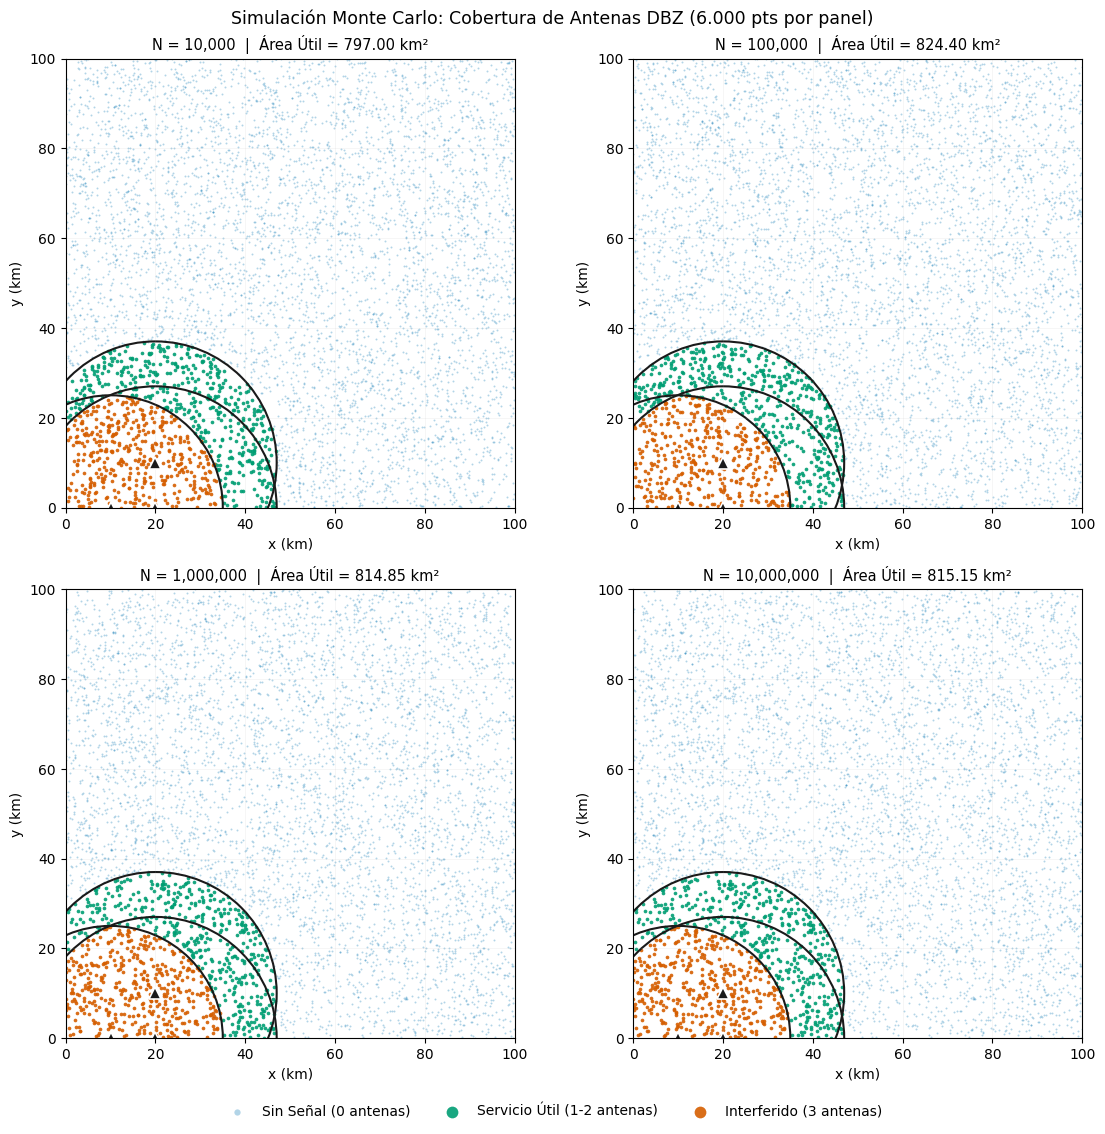

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

RUT = "21.620.910-9"  # Maximiliano Palma
d = [int(c) for c in RUT if c.isdigit()][:8]

ANTENAS = [
    ((d[0] * 10, d[1] * 10), d[2] * 2 + 15),
    ((d[3] * 10, d[4] * 10), d[2] * 2 + 15),
    ((d[6] * 10, d[7] * 10), 25)
]

LADO = 100.0
AREA_TOTAL = 10_000.0
ESCENARIOS = [10_000, 100_000, 1_000_000, 10_000_000]

print("RUT de referencia:", RUT, "-> Dígitos d1..d8 =", d)
for i, ((cx, cy), r) in enumerate(ANTENAS, 1):
    print(f"  Antena {i}: Centro = ({cx}, {cy}) km, Radio = {r} km")

def simular_monte_carlo(N, seed=42, chunk=1_000_000):
    rng = np.random.default_rng(seed)
    conteos = np.zeros(4, dtype=np.int64)
    submuestra = None
    for i in range(0, N, chunk):
        m = min(chunk, N - i)
        x = rng.uniform(0, LADO, m)
        y = rng.uniform(0, LADO, m)
        cob = sum(((x - cx) ** 2 + (y - cy) ** 2 <= r * r) for (cx, cy), r in ANTENAS)
        conteos += np.bincount(cob, minlength=4)
        if submuestra is None:
            submuestra = (x[:6000], y[:6000], cob[:6000])
    return conteos, submuestra

resultados = []
muestras_vis = {}

for N in ESCENARIOS:
    c, mu = simular_monte_carlo(N)
    muestras_vis[N] = mu
    p_util = (c[1] + c[2]) / N
    p_int = c[3] / N
    p_sin = c[0] / N
    ee = AREA_TOTAL * np.sqrt(p_util * (1 - p_util) / N)
    resultados.append((N, AREA_TOTAL * p_util, ee, AREA_TOTAL * p_int, AREA_TOTAL * p_sin))

# Tabla 1: Reporte de Areas
print(f"\n{'N':>12} {'Área Útil (km²)':>16} {'± EE (km²)':>12} {'Interferida (km²)':>18} {'Sin Señal (km²)':>16}")
for N, a_u, e, a_i, a_s in resultados:
    print(f"{N:>12,} {a_u:>16.2f} {e:>12.2f} {a_i:>18.2f} {a_s:>16.2f}")

# Tabla 2: Estudio de Convergencia
ref_area = resultados[-1][1]
print(f"\nReferencia de Alta Precisión (N=10M): {ref_area:.2f} km²")
print(f"{'N':>12} {'Error Absoluto':>15} {'Error Relativo':>15} {'EE Teórico':>12} {'Razón EE':>10}")
prev_ee = None
for N, a_u, e, _, _ in resultados:
    err_abs = abs(a_u - ref_area)
    err_rel = err_abs / ref_area
    razon = f"{e / prev_ee:.3f}" if prev_ee else "-"
    print(f"{N:>12,} {err_abs:>15.2f} {err_rel:>14.4%} {e:>12.2f} {razon:>10}")
    prev_ee = e

# Grafico de 4 paneles con paleta accesible Okabe-Ito
CLASES = [
    ("Sin Señal (0 antenas)", '#0072b2', 2, 0.30),
    ("Servicio Útil (1-2 antenas)", '#009e73', 7, 0.90),
    ("Interferido (3 antenas)", '#d55e00', 7, 0.90)
]

fig, axes = plt.subplots(2, 2, figsize=(11.5, 11.5))
for ax, N in zip(axes.ravel(), ESCENARIOS):
    x, y, cob = muestras_vis[N]
    clase = np.where(cob == 0, 0, np.where(cob == 3, 2, 1))
    for k, (etq, col, s, al) in enumerate(CLASES):
        m = (clase == k)
        ax.scatter(x[m], y[m], c=col, s=s, alpha=al, linewidths=0, label=etq if ax is axes[0, 0] else None)
    for (cx, cy), r in ANTENAS:
        ax.add_patch(plt.Circle((cx, cy), r, fill=False, ec='#1a1a1a', lw=1.5))
        ax.plot(cx, cy, marker='^', color='#1a1a1a', ms=9, mec='white', mew=1.2)
    ax.set_xlim(0, LADO); ax.set_ylim(0, LADO); ax.set_aspect('equal')
    a_u = [f[1] for f in resultados if f[0] == N][0]
    ax.set_title(f"N = {N:,}  |  Área Útil = {a_u:.2f} km²", fontsize=10.5)
    ax.set_xlabel("x (km)"); ax.set_ylabel("y (km)")
    ax.grid(alpha=0.15, lw=0.5)

fig.legend(loc='lower center', ncol=3, frameon=False, markerscale=3.2, fontsize=10, bbox_to_anchor=(0.5, 0.005))
fig.suptitle("Simulación Monte Carlo: Cobertura de Antenas DBZ (6.000 pts por panel)", fontsize=12.5)
fig.tight_layout(rect=[0, 0.035, 1, 1])
plt.savefig("p3_cobertura.png", dpi=120)
plt.show()

### 3.4 Análisis de Resultados y Convergencia de Monte Carlo
Al revisar los 4 escenarios vemos cómo la estimación del área se va estabilizando a medida que aumentamos los puntos. Con 10.000 puntos el área nos dio 797.00 km² con un margen de error de ±27 km², mientras que con 100.000 subió a 824.40 km² con error de ±8.7 km². Ya a partir de 1 millón de puntos el valor se afirma en 814.85 km², y con 10 millones prácticamente no cambia (815.15 km² con menos de 1 km² de error). La diferencia entre 1 millón y 10 millones es de solo 0.3 km², lo que confirma que el resultado ya es muy estable.

Esto se explica por la Ley de los Grandes Números y por cómo funciona Monte Carlo: el error disminuye con la raíz de la cantidad de puntos ($1 / \sqrt{N}$). Como en cada paso multiplicamos las muestras por 10, el error debería bajar dividiéndose por $\sqrt{10}$, que es aproximadamente 0.316. En nuestra tabla calculamos la razón entre errores consecutivos y obtuvimos 0.321, 0.315 y 0.316, lo que coincide casi exacto con la teoría. Esto demuestra que para ganar un decimal más de precisión hay que simular 100 veces más puntos.

Por último, en el gráfico de cobertura se aprecia que las tres antenas quedaron concentradas en la esquina inferior izquierda del mapa debido a los números del RUT. La zona naranja del centro muestra el área donde se cruzan las tres señales (unos 711 km²), donde se produce interferencia y se pierde la señal. Alrededor de ella queda la franja verde con servicio útil de 1 o 2 antenas (unos 815 km²), mientras que más del 84% del terreno (en azul) queda totalmente sin señal, por lo que la empresa tendría que instalar más antenas hacia el noreste.